## GINN-Depth `best.pt` 推理、剖面对比与井验收

这个 notebook 会做几件事：

1. 从 `experiments/ginn_depth/results/.../checkpoints/best.pt` 加载训练好的模型。
2. 使用 `Trainer.predict_volume()` 对整个深度域体做预测，得到阻抗体。
3. 导出 `npy`、`segy`、剖面对比图、井验收图和井验收指标。
4. 额外写出 `run_summary.json`。


In [1]:
import json
import sys
from pathlib import Path

import cigsegy
import lasio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent

src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from cup.petrel.load import (
    extract_rho_log_from_las,
    extract_vp_log_from_las,
    import_well_heads_petrel,
)
from cup.seismic.survey import open_survey
from ginn_depth.config import DepthGINNConfig
from ginn_depth.trainer import Trainer

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
repo_root

WindowsPath('c:/Users/WangQinZhuo/Program/libra_workflow_standardize')

In [2]:
checkpoint_path = repo_root / "experiments" / "ginn_depth" / "results" / "2026042903" / "checkpoints" / "best.pt"
output_dir = repo_root / "data" / "output_ginn_inversion_depth_2026042903"
output_dir.mkdir(parents=True, exist_ok=True)

slice_mode = "inline"  # 可选: "inline" 或 "xline"
slice_index = None  # None 表示默认取中间剖面
clip_percentiles = (1.0, 99.0)
ai_display_min = 0.0
ai_display_max = 20000.0

las_dir = repo_root / "data" / "vertical_well_las_target_qyz"
well_heads_file = repo_root / "data" / "raw" / "well_heads"

if not checkpoint_path.exists():
    raise FileNotFoundError(checkpoint_path)

checkpoint_path

WindowsPath('c:/Users/WangQinZhuo/Program/libra_workflow_standardize/experiments/ginn_depth/results/2026042903/checkpoints/best.pt')

In [3]:
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
cfg_payload = checkpoint["config"]
cfg = DepthGINNConfig.from_dict(cfg_payload) if isinstance(cfg_payload, dict) else cfg_payload
cfg.device = "cuda" if torch.cuda.is_available() else "cpu"

trainer = Trainer(cfg)
trainer.model.load_state_dict(checkpoint["model_state_dict"])
trainer.model.eval()

checkpoint_dir = checkpoint_path.parent
training_metrics_path = checkpoint_dir / "metrics.csv"
training_summary_path = checkpoint_dir / "run_summary.json"

print(f"Loaded checkpoint: {checkpoint_path}")
print(f"Epoch: {checkpoint['epoch']}")
print(f"Best loss: {checkpoint['best_loss']:.6f}")
print(f"Best epoch: {checkpoint.get('best_epoch')}")
print(f"Device: {trainer.device}")
print(f"Geometry: {trainer.geometry}")
print(f"Input channels: {getattr(trainer.dataset, 'input_channel_names', None)}")
print(
    "Normalization:",
    {
        "seis_rms": trainer.dataset.seis_rms,
        "lfm_scale": trainer.dataset.lfm_scale,
        "dynamic_gain_median": getattr(trainer.dataset, "dynamic_gain_median", None),
    },
)
print(f"Training run summary: {training_summary_path} | exists={training_summary_path.exists()}")
print(f"Training metrics CSV: {training_metrics_path} | exists={training_metrics_path.exists()}")

if training_summary_path.exists():
    training_summary = json.loads(training_summary_path.read_text(encoding="utf-8"))
    print("Training data summary:", training_summary.get("data", {}))
    print("Training model summary:", training_summary.get("model", {}))

if training_metrics_path.exists():
    training_metrics_df = pd.read_csv(training_metrics_path)
    print(f"Training metrics rows: {len(training_metrics_df)}")
    if not training_metrics_df.empty:
        print("Training metrics tail:")
        display(training_metrics_df.tail(5))


100%|██████████| 601/601 [00:02<00:00, 252.02it/s]


Loaded checkpoint: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\experiments\ginn_depth\results\2026042903\checkpoints\best.pt
Epoch: 6
Best loss: 0.017595
Best epoch: 7
Device: cuda
Geometry: {'n_il': 601, 'inline_min': 1501.0, 'inline_max': 2101.0, 'inline_step': 1.0, 'n_xl': 801, 'xline_min': 3799.0, 'xline_max': 6999.0, 'xline_step': 4.0, 'n_sample': 551, 'sample_min': 4750.0, 'sample_max': 7500.0, 'sample_step': 5.0, 'sample_domain': 'depth', 'sample_unit': 'm'}
Input channels: ('seismic', 'ai_lfm', 'mask', 'dynamic_gain_log_ratio')
Normalization: {'seis_rms': 7334.7939453126, 'lfm_scale': 16834.8789062501, 'dynamic_gain_median': 36.902069091796875}
Training run summary: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\experiments\ginn_depth\results\2026042903\checkpoints\run_summary.json | exists=True
Training metrics CSV: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\experiments\ginn_depth\results\2026042903\checkpoints\metrics.csv | exists=True
Traini

,epoch,global_step,lr,epoch_time_s,train_loss,train_waveform_mae,train_residual_l2,train_l2_term,train_tv_term,train_residual_tv,...,val_tv_term,val_residual_tv,val_residual_mean,monitor_name,monitor_value,best_loss,best_epoch,is_best,epochs_without_improvement,early_stop_triggered
10,11,295108,0.000886,193.299603,0.020421,0.018367,0.009596,0.000480,0.001574,0.015741,...,0.001467,0.014673,0.024753,val_loss,0.030642,0.017595,7,False,4,False
11,12,321936,0.000866,181.212001,0.020089,0.017885,0.009634,0.000482,0.001722,0.017225,...,0.001560,0.015598,0.023420,val_loss,0.018784,0.017595,7,False,5,False
12,13,348764,0.000844,181.058458,0.019720,0.017371,0.009637,0.000482,0.001867,0.018668,...,0.001622,0.016222,0.024339,val_loss,0.025286,0.017595,7,False,6,False
13,14,375592,0.000821,180.936540,0.019462,0.017035,0.009651,0.000483,0.001944,0.019445,...,0.001753,0.017533,0.023734,val_loss,0.021467,0.017595,7,False,7,False
14,15,402420,0.000796,180.600518,0.019189,0.016727,0.009722,0.000486,0.001976,0.019756,...,0.001824,0.018245,0.022439,val_loss,0.018093,0.017595,7,False,8,True


In [4]:
pred_volume = trainer.predict_volume()

n_il = int(trainer.geometry["n_il"])
n_xl = int(trainer.geometry["n_xl"])
n_sample = int(trainer.geometry["n_sample"])

lfm_volume = trainer.dataset.ai_lfm_flat.reshape(n_il, n_xl, n_sample)
mask_volume = trainer.dataset._mask_flat.reshape(n_il, n_xl, n_sample)


def sampled_values(volume: np.ndarray, max_samples: int = 2_000_000) -> np.ndarray:
    flat = np.asarray(volume).ravel()
    stride = max(1, int(np.ceil(flat.size / max_samples)))
    values = flat[::stride]
    return values[np.isfinite(values)]


def sampled_difference(left: np.ndarray, right: np.ndarray, max_samples: int = 2_000_000) -> np.ndarray:
    left_flat = np.asarray(left).ravel()
    right_flat = np.asarray(right).ravel()
    if left_flat.shape != right_flat.shape:
        raise ValueError(f"shape mismatch: {left.shape} vs {right.shape}")
    stride = max(1, int(np.ceil(left_flat.size / max_samples)))
    values = left_flat[::stride] - right_flat[::stride]
    return values[np.isfinite(values)]


def print_sampled_stats(name: str, values: np.ndarray) -> None:
    values = values[np.isfinite(values)]
    if values.size == 0:
        print(f"{name}: no finite sampled values")
        return
    print(
        f"{name}: sampled_n={values.size}, min={values.min():.2f}, "
        f"p01={np.percentile(values, 1):.2f}, median={np.median(values):.2f}, "
        f"p99={np.percentile(values, 99):.2f}, max={values.max():.2f}, mean={values.mean():.2f}"
    )


prediction_path = output_dir / "pred_volume_best.npy"
np.save(prediction_path, pred_volume.astype(np.float32))

pred_sample = sampled_values(pred_volume)
lfm_sample = sampled_values(lfm_volume)
diff_sample = sampled_difference(pred_volume, lfm_volume)

print("Prediction volume shape:", pred_volume.shape)
print("LFM volume shape:", lfm_volume.shape)
print("Mask volume shape:", mask_volume.shape)
print(f"Mask coverage: {float(mask_volume.mean()):.4%}")
print_sampled_stats("Prediction AI", pred_sample)
print_sampled_stats("LFM AI", lfm_sample)
print_sampled_stats("Prediction - LFM", diff_sample)
print("Saved prediction to:", prediction_path)


Prediction volume shape: (601, 801, 551)
LFM volume shape: (601, 801, 551)
Mask volume shape: (601, 801, 551)
Mask coverage: 18.8946%
Prediction AI: sampled_n=1994376, min=7416.78, p01=10050.34, median=13262.25, p99=15065.27, max=19672.70, mean=12491.66
LFM AI: sampled_n=1994376, min=9410.21, p01=10068.58, median=13096.17, p99=13596.68, max=16773.90, mean=12386.73
Prediction - LFM: sampled_n=1994376, min=-6496.13, p01=-1918.58, median=0.00, p99=2647.42, max=7676.69, mean=104.92
Saved prediction to: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_ginn_inversion_depth_2026042903\pred_volume_best.npy


In [5]:
def resolve_slice_index(mode: str, index: int | None, geometry: dict) -> int:
    if mode not in {"inline", "xline"}:
        raise ValueError(f"slice_mode must be 'inline' or 'xline', got {mode!r}")
    size = int(geometry["n_il"] if mode == "inline" else geometry["n_xl"])
    if index is None:
        return size // 2
    if not (0 <= index < size):
        raise IndexError(f"slice_index={index} out of range for {mode} size={size}")
    return index


def extract_section(volume: np.ndarray, mode: str, index: int) -> np.ndarray:
    if mode == "inline":
        return volume[index, :, :].T
    if mode == "xline":
        return volume[:, index, :].T
    raise ValueError(mode)


def extract_mask_section(mask: np.ndarray, mode: str, index: int) -> np.ndarray:
    if mode == "inline":
        return mask[index, :, :].T
    if mode == "xline":
        return mask[:, index, :].T
    raise ValueError(mode)


def robust_limits(*arrays: np.ndarray, percentiles=(1.0, 99.0)) -> tuple[float, float]:
    values = np.concatenate([np.asarray(arr, dtype=np.float32).ravel() for arr in arrays])
    return tuple(np.percentile(values, percentiles))


def sample_axis_depth_m(geometry: dict) -> np.ndarray:
    n_sample = int(geometry["n_sample"])
    sample_min = float(geometry["sample_min"])
    sample_step = float(geometry["sample_step"])
    return sample_min + np.arange(n_sample, dtype=np.float64) * sample_step


def bilinear_trace_from_volume(volume: np.ndarray, survey_ctx, x: float, y: float) -> np.ndarray:
    i_float, j_float = survey_ctx.coord_to_index(x, y)
    i0 = int(np.floor(i_float))
    i1 = int(np.ceil(i_float))
    j0 = int(np.floor(j_float))
    j1 = int(np.ceil(j_float))
    i1 = min(i1, volume.shape[0] - 1)
    j1 = min(j1, volume.shape[1] - 1)
    wi = float(i_float - i0)
    wj = float(j_float - j0)
    t00 = volume[i0, j0, :]
    t01 = volume[i0, j1, :]
    t10 = volume[i1, j0, :]
    t11 = volume[i1, j1, :]
    return (1.0 - wi) * (1.0 - wj) * t00 + (1.0 - wi) * wj * t01 + wi * (1.0 - wj) * t10 + wi * wj * t11


def collect_las_references(las_dir: Path) -> dict[str, Path]:
    refs: dict[str, Path] = {}
    for las_path in sorted(Path(las_dir).glob("*.las")):
        refs[las_path.stem.upper()] = las_path
    return refs


def extract_ai_reference_from_las(las_path: Path) -> tuple[np.ndarray, np.ndarray]:
    las_file = lasio.read(las_path)
    vp_log = extract_vp_log_from_las(las_file, unit="us/m")
    rho_log = extract_rho_log_from_las(las_file, unit="g/cm3")
    depth = np.asarray(vp_log.basis, dtype=np.float64)
    vp = np.asarray(vp_log.values, dtype=np.float64)
    rho_depth = np.asarray(rho_log.basis, dtype=np.float64)
    rho = np.asarray(rho_log.values, dtype=np.float64)
    if rho_depth.shape != depth.shape or not np.allclose(rho_depth, depth):
        rho = np.interp(depth, rho_depth, rho)
    ai = vp * rho
    finite = np.isfinite(depth) & np.isfinite(ai)
    return depth[finite], ai[finite]


resolved_slice_index = resolve_slice_index(slice_mode, slice_index, trainer.geometry)
pred_section = extract_section(pred_volume, slice_mode, resolved_slice_index)
lfm_section = extract_section(lfm_volume, slice_mode, resolved_slice_index)
mask_section = extract_mask_section(mask_volume, slice_mode, resolved_slice_index)
diff_section = pred_section - lfm_section

auto_vmin, auto_vmax = robust_limits(pred_section, lfm_section, percentiles=clip_percentiles)
shared_vmin = auto_vmin if ai_display_min is None else float(ai_display_min)
shared_vmax = auto_vmax if ai_display_max is None else float(ai_display_max)
diff_abs = np.percentile(np.abs(diff_section), clip_percentiles[1])

print(f"Slice mode: {slice_mode}")
print(f"Slice index: {resolved_slice_index}")
print(f"Shared display range: [{shared_vmin:.2f}, {shared_vmax:.2f}]")
print(f"Diff display abs range: +/-{diff_abs:.2f}")

Slice mode: inline
Slice index: 300
Shared display range: [0.00, 20000.00]
Diff display abs range: +/-3030.45


Saved figure to: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_ginn_inversion_depth_2026042903\inline_0300_prediction_vs_lfm.png


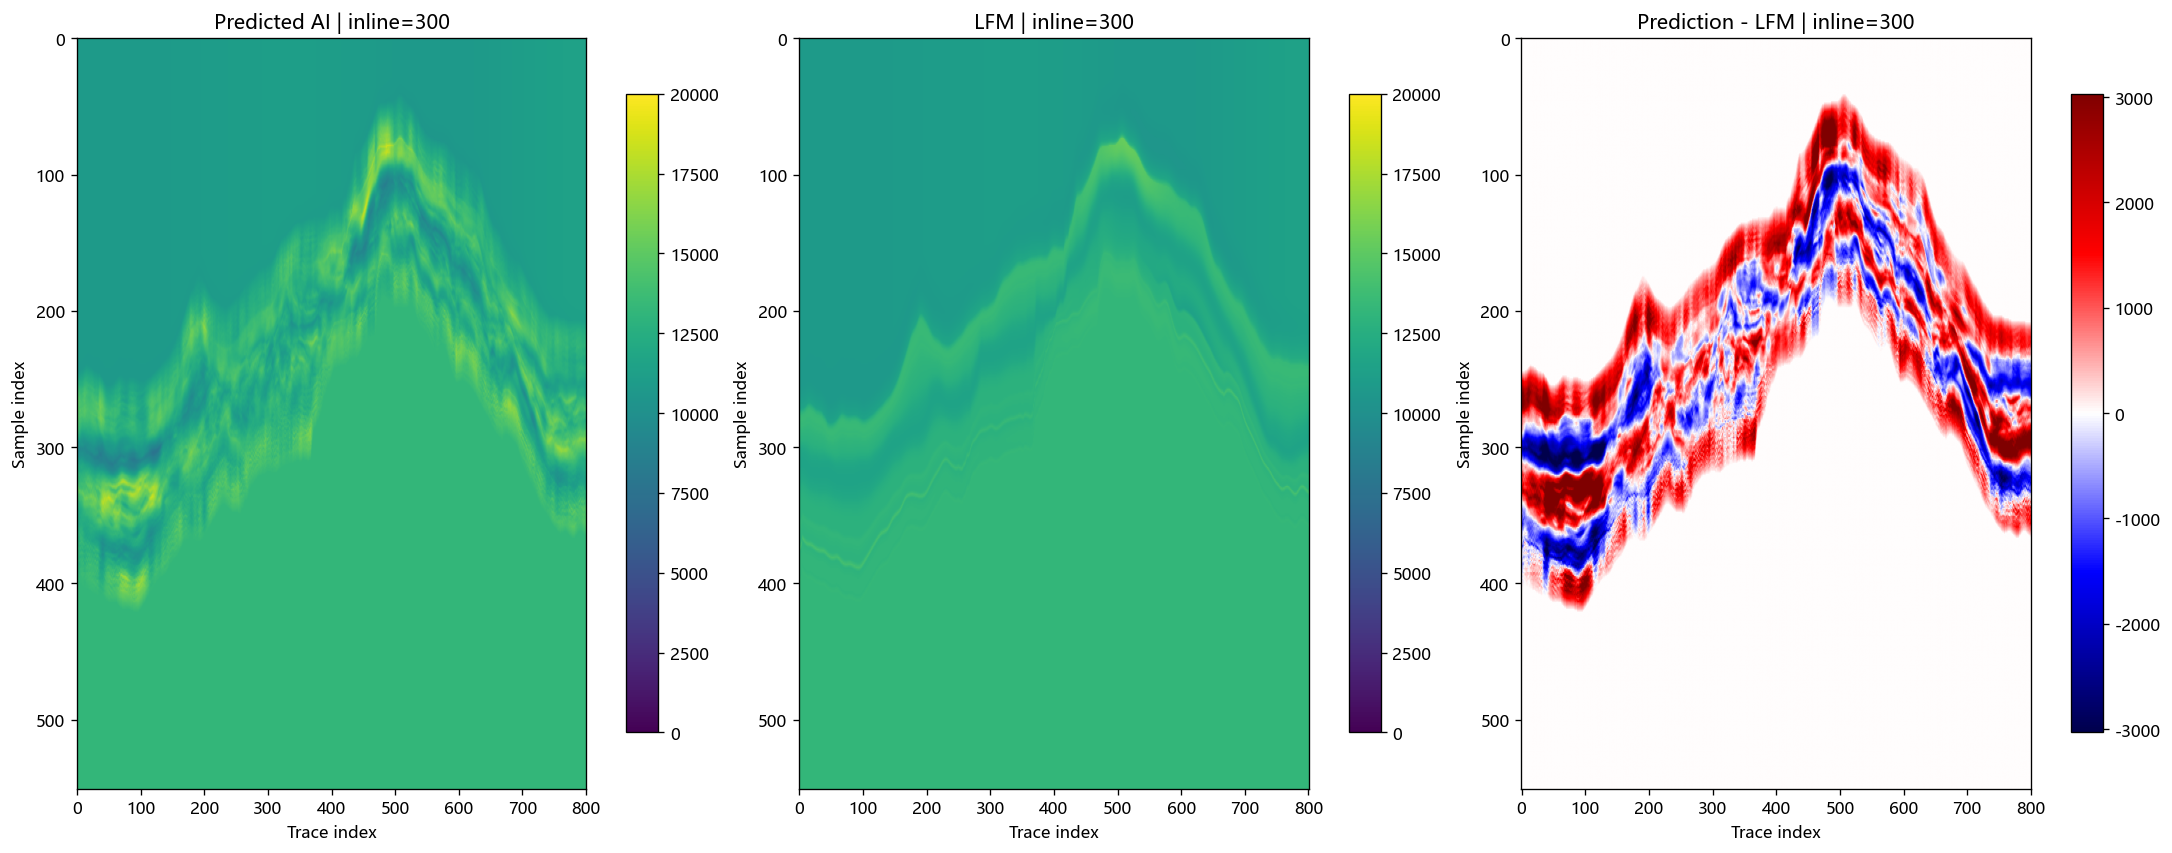

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), constrained_layout=True)

im0 = axes[0].imshow(pred_section, cmap="viridis", aspect="auto", origin="upper", vmin=shared_vmin, vmax=shared_vmax)
axes[0].set_title(f"Predicted AI | {slice_mode}={resolved_slice_index}")
axes[0].set_xlabel("Trace index")
axes[0].set_ylabel("Sample index")
fig.colorbar(im0, ax=axes[0], shrink=0.85)

im1 = axes[1].imshow(lfm_section, cmap="viridis", aspect="auto", origin="upper", vmin=shared_vmin, vmax=shared_vmax)
axes[1].set_title(f"LFM | {slice_mode}={resolved_slice_index}")
axes[1].set_xlabel("Trace index")
axes[1].set_ylabel("Sample index")
fig.colorbar(im1, ax=axes[1], shrink=0.85)

im2 = axes[2].imshow(diff_section, cmap="seismic", aspect="auto", origin="upper", vmin=-diff_abs, vmax=diff_abs)
axes[2].set_title(f"Prediction - LFM | {slice_mode}={resolved_slice_index}")
axes[2].set_xlabel("Trace index")
axes[2].set_ylabel("Sample index")
fig.colorbar(im2, ax=axes[2], shrink=0.85)

figure_path = output_dir / f"{slice_mode}_{resolved_slice_index:04d}_prediction_vs_lfm.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
print("Saved figure to:", figure_path)
plt.show()

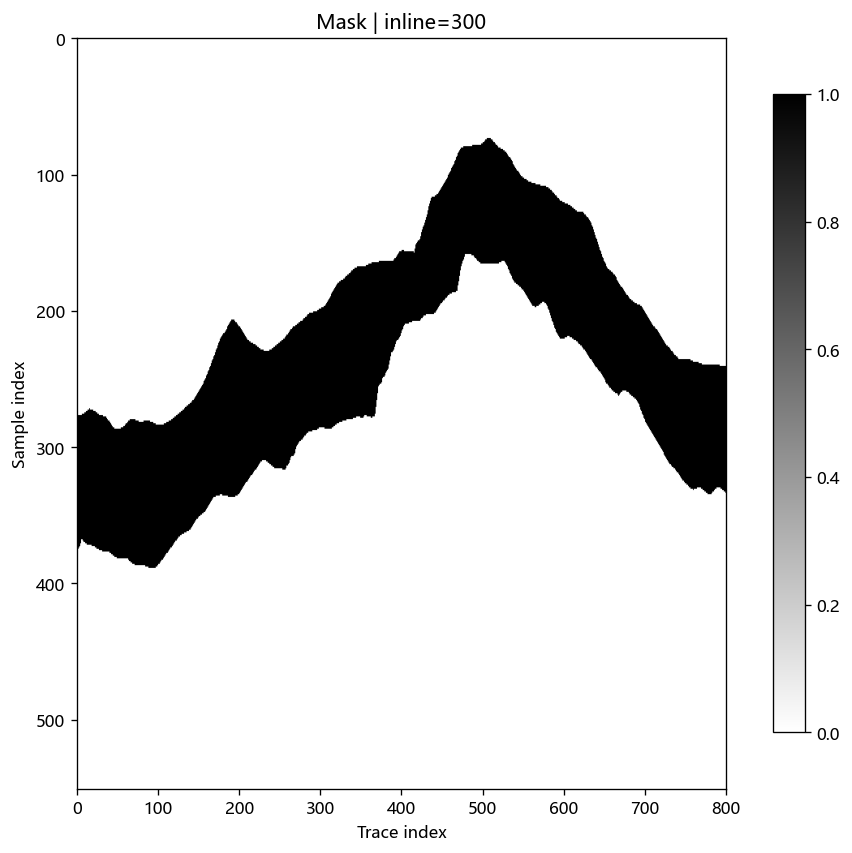

In [7]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
mask_image = np.where(mask_section, 1.0, 0.0)
im = ax.imshow(mask_image, cmap="gray_r", aspect="auto", origin="upper", vmin=0.0, vmax=1.0)
ax.set_title(f"Mask | {slice_mode}={resolved_slice_index}")
ax.set_xlabel("Trace index")
ax.set_ylabel("Sample index")
fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()

In [8]:
orig_segy_path = Path(cfg.seismic_file)
if not orig_segy_path.exists():
    raise FileNotFoundError(orig_segy_path)

keylocs = [cfg.segy_iline, cfg.segy_xline, cfg.segy_istep, cfg.segy_xstep]
pred_segy_path = output_dir / "pred_volume_best.segy"
pred_volume_export = np.ascontiguousarray(pred_volume.astype(np.float32))


def build_textual_header(title: str, lines: list[str]) -> str:
    rows = [f"C{idx:>2d} {text}"[:80].ljust(80) for idx, text in enumerate([title, *lines], start=1)]
    rows.extend([f"C{idx:>2d}".ljust(80) for idx in range(len(rows) + 1, 41)])
    textual = "".join(rows)
    if len(textual) != 3200:
        raise ValueError(f"Expected 3200-char textual header, got {len(textual)}")
    return textual


pred_textual = build_textual_header(
    "GINN-Depth predicted impedance volume",
    [
        f"checkpoint={checkpoint_path.name}",
        f"epoch={checkpoint['epoch']}",
        f"best_loss={checkpoint['best_loss']:.6f}",
    ],
)

cigsegy.create_by_sharing_header(
    str(pred_segy_path),
    str(orig_segy_path),
    pred_volume_export,
    keylocs=keylocs,
    textual=pred_textual,
)

print("Exported predicted impedance SEG-Y to:", pred_segy_path)

Exported predicted impedance SEG-Y to: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_ginn_inversion_depth_2026042903\pred_volume_best.segy


执行井验收...


100%|██████████| 481401/481401 [00:00<00:00, 2528086.38it/s]


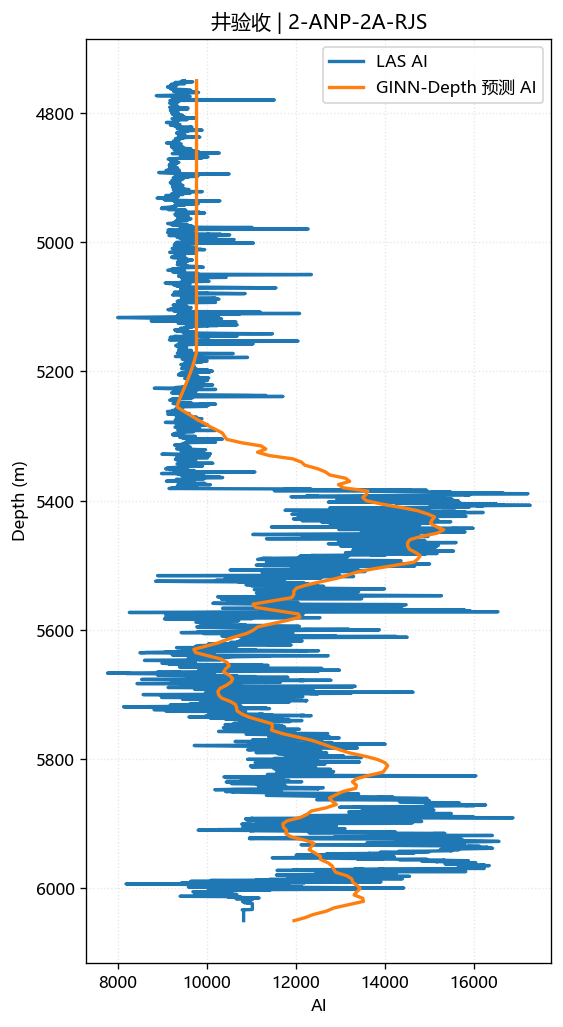

已保存井验收图: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_ginn_inversion_depth_2026042903\well_qc_2-ANP-2A-RJS.png
已保存井验收指标: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_ginn_inversion_depth_2026042903\well_qc_metrics.csv
已保存运行摘要: c:\Users\WangQinZhuo\Program\libra_workflow_standardize\data\output_ginn_inversion_depth_2026042903\run_summary.json


,well_name,n_samples,mae,rmse,bias,corr,reference_file
0,2-ANP-2A-RJS,12986,1040.964005,1434.658365,403.209043,0.714801,2-ANP-2A-RJS.las
8,NW8,11311,1130.689329,1656.931181,405.077959,0.432814,NW8.las
6,NW11,4895,1238.651091,1694.635595,-36.467790,0.342366,NW11.las
5,L9-NW4A,5265,1383.474148,1736.812759,203.038723,0.329367,L9-NW4A.las
2,L3-NW2A,6514,1500.239731,1835.188658,771.576787,0.084677,L3-NW2A.las
7,NW7,4187,1535.831654,1929.135260,248.715488,0.375538,NW7.las
1,L1-NW1,5812,1945.871556,2524.671170,-286.323151,0.229105,L1-NW1.las
3,L5-NW5,9140,2203.404433,2829.558262,-585.994838,0.220533,L5-NW5.las
4,L6-NW3A,6119,2432.762986,2988.730316,983.521351,-0.404619,L6-NW3A.las


In [9]:
print("执行井验收...")
survey_ctx = open_survey(
    cfg.seismic_file,
    seismic_type="segy",
    segy_options={
        "iline": cfg.segy_iline,
        "xline": cfg.segy_xline,
        "istep": cfg.segy_istep,
        "xstep": cfg.segy_xstep,
    },
)
sample_axis_m = sample_axis_depth_m(trainer.geometry)

well_heads = import_well_heads_petrel(well_heads_file)
well_heads = well_heads.assign(Name_norm=well_heads["Name"].str.upper())
reference_files = collect_las_references(las_dir)

metrics = []
example_plot_done = False

for well_name_norm, las_path in reference_files.items():
    head_match = well_heads.loc[well_heads["Name_norm"] == well_name_norm]
    if head_match.empty:
        print(f"跳过 {well_name_norm}: 井头未匹配")
        continue

    head = head_match.iloc[0]
    ref_depth, ref_ai = extract_ai_reference_from_las(las_path)
    pred_trace = bilinear_trace_from_volume(pred_volume, survey_ctx, float(head["Surface X"]), float(head["Surface Y"]))
    pred_ai = np.interp(ref_depth, sample_axis_m, pred_trace, left=np.nan, right=np.nan)
    valid = np.isfinite(pred_ai) & np.isfinite(ref_ai)
    if not np.any(valid):
        print(f"跳过 {well_name_norm}: 无重叠采样")
        continue

    diff = pred_ai[valid] - ref_ai[valid]
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff**2)))
    bias = float(np.mean(diff))
    corr = float(np.corrcoef(pred_ai[valid], ref_ai[valid])[0, 1]) if np.sum(valid) > 1 else np.nan

    metrics.append(
        {
            "well_name": head["Name"],
            "n_samples": int(np.sum(valid)),
            "mae": mae,
            "rmse": rmse,
            "bias": bias,
            "corr": corr,
            "reference_file": las_path.name,
        }
    )

    if not example_plot_done:
        fig, ax = plt.subplots(figsize=(5, 10))
        ax.plot(ref_ai[valid], ref_depth[valid], label="LAS AI", lw=2)
        ax.plot(pred_ai[valid], ref_depth[valid], label="GINN-Depth 预测 AI", lw=2)
        ax.invert_yaxis()
        ax.set_xlabel("AI")
        ax.set_ylabel("Depth (m)")
        ax.set_title(f"井验收 | {head['Name']}")
        ax.legend(loc="best")
        ax.grid(True, alpha=0.3, linestyle=":")
        qc_plot_path = output_dir / f"well_qc_{str(head['Name']).replace('/', '_')}.png"
        fig.savefig(qc_plot_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("已保存井验收图:", qc_plot_path)
        example_plot_done = True

metrics_df = pd.DataFrame(metrics)
if not metrics_df.empty:
    metrics_df = metrics_df.sort_values("rmse")
metrics_csv_path = output_dir / "well_qc_metrics.csv"
metrics_df.to_csv(metrics_csv_path, index=False)
print("已保存井验收指标:", metrics_csv_path)

run_summary = {
    "checkpoint_path": str(checkpoint_path),
    "epoch": int(checkpoint["epoch"]),
    "best_loss": float(checkpoint["best_loss"]),
    "device": str(trainer.device),
    "prediction_path": str(prediction_path),
    "pred_segy_path": str(pred_segy_path),
    "slice_mode": slice_mode,
    "slice_index": int(resolved_slice_index),
    "slice_figure_path": str(figure_path),
    "well_qc_metrics_path": str(metrics_csv_path),
    "n_il": int(n_il),
    "n_xl": int(n_xl),
    "n_sample": int(n_sample),
    "sample_min": float(trainer.geometry["sample_min"]),
    "sample_max": float(trainer.geometry["sample_max"]),
    "sample_step": float(trainer.geometry["sample_step"]),
    "n_wells_qc": int(len(metrics_df)),
    "well_qc_mean_rmse": None if metrics_df.empty else float(metrics_df["rmse"].mean()),
    "well_qc_mean_mae": None if metrics_df.empty else float(metrics_df["mae"].mean()),
    "well_qc_mean_corr": None if metrics_df.empty else float(metrics_df["corr"].mean()),
}
run_summary_path = output_dir / "run_summary.json"
with run_summary_path.open("w", encoding="utf-8") as fp:
    json.dump(run_summary, fp, ensure_ascii=False, indent=2)
print("已保存运行摘要:", run_summary_path)

metrics_df